In [1]:
# most of this cell's code was run in notebook 'primeTau1oct25no2'
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def tau(n):
    def step1(n, k):
        return 35*k^4 - 52*k^3*n + 18*k^2*n^2
    def step2(n, k):
        return sigma(k) * sigma(n - k)
    def step3(n):
        ans = 0
        for k in range(1, n):
            ans += step1(n, k) * step2(n, k)
        return 24*ans
    return n^4 * sigma(n) - step3(n)





tau_list =[] 
for k in range(1, 501):
    tau_list.append([k,tau(k)])
    if k%100==0:
        print(k)

with open('/Users/barrybrent/data/run18oct25no13.txt', 'wb') as wfile:
    pickle.dump(tau_list, wfile) #output snipped

with open('/Users/barrybrent/data/run18oct25no13.txt', 'rb') as rfile:
    tau_list = pickle.load(rfile)
h_list=[[0,1]]+tau_list 
j_list=[(0,0)] # <<<<<<<<<<<<<<<<<< c=0
for n in [1..500]:# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r][1] 
    j_n=n*h_list[n][1]-sm
    j_list.append((n,j_n))

print(h_list[:10])
print()
print(j_list[:10])
    
with open('/Users/barrybrent/data/run18oct25no14.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) # ouput snipped

100
200
300
400
500
[[0, 1], [1, 1], [2, -24], [3, 252], [4, -1472], [5, 4830], [6, -6048], [7, -16744], [8, 84480], [9, -113643]]

[(0, 0), (1, 1), (2, -49), (3, 829), (4, -8145), (5, 66011), (6, -583645), (7, 5566247), (8, -51805777), (9, 472068856)]


In [4]:
primeTau(1)

-24

PARI stack size set to 7000000000 bytes, maximum size set to 7000002560
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440
460
480
500
(1, 0.04722920258839925)
(2, 0.04808111985524496)
(3, 0.048206488291422524)
(4, 0.04863541920979818)
(5, 0.048679320017496745)
(6, 0.04874550501505534)
(7, 0.048783334096272786)
(8, 0.048824000358581546)
(9, 0.048890101909637454)
(10, 0.048955150445302326)
(11, 0.04904663562774658)
(12, 0.04915040334065755)
(13, 0.04924386739730835)
(14, 0.049367018540700275)
(15, 0.04949973424275716)
(16, 0.049651900927225746)
(17, 0.04982980092366537)
(18, 0.05001500447591146)
(19, 0.05025145212809245)
(20, 0.05052766799926758)
(21, 0.050850168863932295)
(22, 0.051145251592000326)
(23, 0.051482752958933516)
(24, 0.05188555320103963)
(25, 0.05234386920928955)
(26, 0.05293171803156535)
(27, 0.05341073671976725)
(28, 0.05401325225830078)
(29, 0.05463827053705851)
(30, 0.05526253382364909)
(31, 0.05597083568572998)
(32, 0.05676211913426717

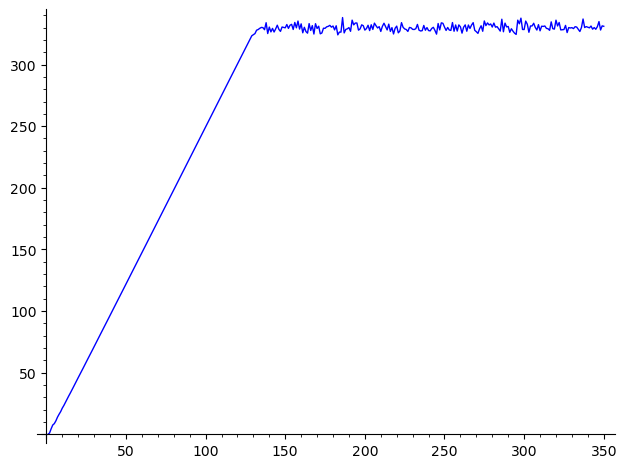

LOGS MINIMUM MODULI


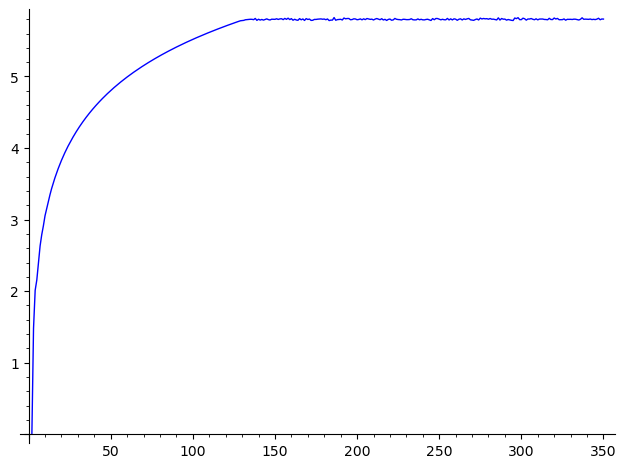

minimum logarithm of minimum modulus: 0.00000000000000000000000000000


In [3]:
import pickle
from sage.all import sigma, nth_prime
import ast
import time
start=time.time()
# Increase PARI stack size to handle large polynomial root computations
pari.allocatemem(7*10^9)  # Allocate 7GB for PARI stack

def tau(n):
    def step1(n, k):
        return 35*k^4 - 52*k^3*n + 18*k^2*n^2
    def step2(n, k):
        return sigma(k) * sigma(n - k)
    def step3(n):
        ans = 0
        for k in range(1, n):
            ans += step1(n, k) * step2(n, k)
        return 24*ans
    return n^4 * sigma(n) - step3(n)

def h(n):
    if n>0:
        return tau(n) # i.e., tauPrime(n)
    if n==0:
        return 1

tau_list =[] 
for k in range(1, 520):
    tau_list.append([k,tau(k)])
    if k%20==0:
        print(k)

with open('/Users/barrybrent/data2/run2april26no11.txt', 'wb') as wfile:
    pickle.dump(tau_list, wfile) #output snipped


h_list=[[0,1]]+tau_list 
j_list=[(0,0)] # <<<<<<<<<<<<<<<<<< c=0
for n in [1..500]:# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r][1] 
    j_n=n*h_list[n][1]-sm
    j_list.append((n,j_n))


with open('/Users/barrybrent/data2/run2april26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) #output snipped

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()


from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable
matrix_list=[]
charpol_list=[]
roots_list=[]
mins_list=[]
log_mins_list=[]
dets=[]
tests=[]
for n in range(1, 351):
    elapsed=(time.time()-start)/60
    print((n,elapsed))
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) ### DEFORMED
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    # compute absolute value for each root (before any conversion)
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        if minn>0:
            log_minn=log(minn)
            log_mins_list.append((n,log_minn))
        
        
p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()
p = list_plot(log_mins_list, plotjoined=True, axes_labels=['', ''])
print("LOGS MINIMUM MODULI")
p.show()
mml=[pair[1] for pair in log_mins_list]
print("minimum logarithm of minimum modulus:",min(mml))
        


with open('/Users/barrybrent/data2/run2apr26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run2apr26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run2apr26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run1apr26no16.txt', 'wb') as wfile: ### lost
    pickle.dump(dets, wfile) #output snipped
    
with open('/Users/barrybrent/data2/run2apr26no17.txt', 'wb') as wfile:
    pickle.dump(log_mins_list, wfile) #output snipped

Data range: n = 1 to 350
Number of data points: 350
Min modulus range: 0.000000 to 338.104615

Detrending: Savitzky-Golay filter, window = 61, poly order = 3
  lag-1 autocorrelation of residuals = 0.0023
  Detrended data std dev: 2.2965

AR(1) lag-1 autocorrelation (rho): 0.0023
Frequency bins tested: 172
Bonferroni-corrected per-bin alpha: 95% -> 0.000291,  99% -> 0.000058

SIGNIFICANT PERIODICITIES  (period <= N/3 = 117, Bonferroni-corrected)
  No peaks exceed the Bonferroni-corrected significance threshold.
  --> The data has no statistically significant periodicity.
  (Period ratios are not computed when no peaks are significant.)


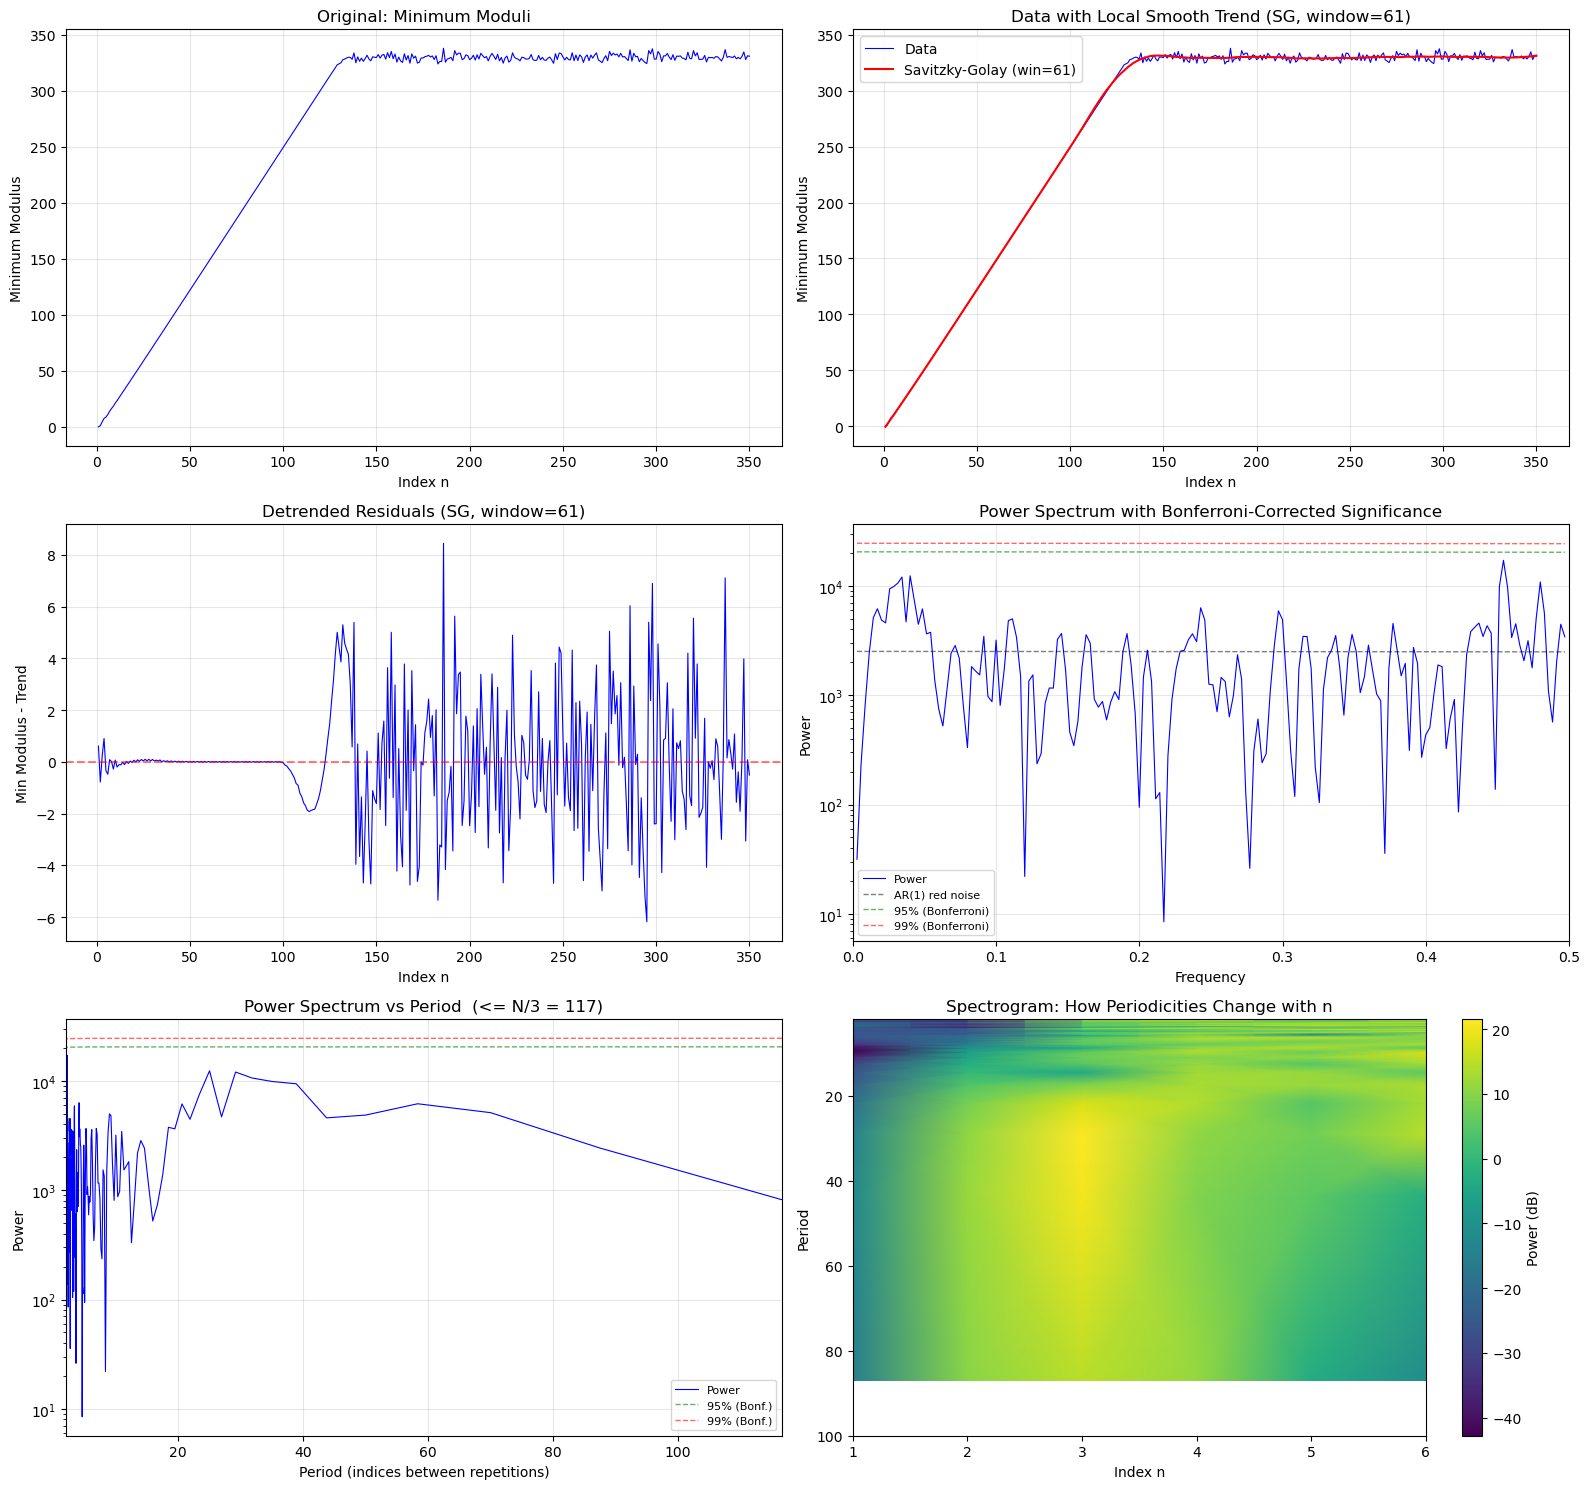


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run2apr26no15.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v4)
#
# Key fix in this version: MULTIPLE TESTING CORRECTION.
#
# With N/2 ~ 175 frequency bins, a 95% single-bin threshold will produce
# ~9 false positives purely by chance, even for white noise. Previous
# versions didn't account for this, so plateau noise peaks were
# incorrectly flagged as "significant periodicities."
#
# This version applies a Bonferroni correction: the per-bin significance
# level is divided by the number of independent frequency bins tested,
# so the *family-wise* false positive rate stays at 5% (or 1%).
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. LOCAL SMOOTHING DETREND  (Savitzky-Golay)
# ==============================================================================
sg_poly_order = 3

candidate_windows = [w for w in range(21, min(N//2, 151), 10) if w % 2 == 1]

best_win, best_score = candidate_windows[0], np.inf
sg_results = {}
for win in candidate_windows:
    trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
    resid = minmoduli - trend
    r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    sg_results[win] = (trend, resid, r1)
    if r1 < best_score:
        best_score = r1
        best_win = win

smooth_trend, detrended, _ = sg_results[best_win]

print(f"\nDetrending: Savitzky-Golay filter, window = {best_win}, poly order = {sg_poly_order}")
print(f"  lag-1 autocorrelation of residuals = {best_score:.4f}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
max_credible_period = N / 3.0
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
# Per-bin alpha = family_alpha / n_tests
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

print("\n" + "="*75)
print(f"SIGNIFICANT PERIODICITIES  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
    # Period ratios: fundamental (rank 1) to each subsequent peak
    if len(significant_peaks) >= 2:
        fund_idx = significant_peaks[0][0]
        fund_period = periods[fund_idx]
        print(f"\n{'':>6}PERIOD RATIOS  (fundamental / peak)")
        print(f"{'':>6}Fundamental period: {fund_period:.2f}")
        print(f"{'':>6}{'-'*55}")
        print(f"{'':>6}{'Rank':<6} {'Period':<12} {'T_fund / T_peak':<18} {'Nearest int':<12}")
        print(f"{'':>6}{'-'*55}")
        for rank, (pi, level) in enumerate(significant_peaks[1:15], 2):
            ratio = fund_period / periods[pi]
            nearest = round(ratio)
            print(f"{'':>6}{rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     {nearest:>6}")
    elif len(significant_peaks) == 1:
        print(f"\n  Only one significant peak (period = {periods[significant_peaks[0][0]]:.2f}); "
              f"no ratios to compute.")
else:
    print("  No peaks exceed the Bonferroni-corrected significance threshold.")
    print("  --> The data has no statistically significant periodicity.")
    print("  (Period ratios are not computed when no peaks are significant.)")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=f'Savitzky-Golay (win={best_win})')
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Local Smooth Trend (SG, window={best_win})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals (SG, window={best_win})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)

